<img src="../imgs/Practica_2/logo_pokemon.png" alt="Modulo IV" width="350" style="display: block; margin: 0 auto;">

<h1 style="background-color:#F54927; color:white;">Práctica 2: Clasificación de Pokemon - Red Neuronal Convolucional </h1>

**Alumna:** Erika Margarita Villaobos Martínez

**Fecha de entrega:** 19 de marzo 2026

___

<h2 style="background-color:#FAA493; color:#595959;">Paso 0: Librerias y lectura de archivos </h2> 

<h2 style="color:#F54927; font-size: 1.2em; font-weight: bold;"> Librerias </h2>

In [53]:
## Lectura de archivos y generales
import os
import shutil
import pandas as pd

## Gráficos
import matplotlib.pyplot as plt

## Imágenes
from PIL import Image

## TensorFlow
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

## Scikit-learn
from sklearn.preprocessing import MultiLabelBinarizer

In [2]:
SEED = 42

<h2 style="color:#F54927; font-size: 1.2em; font-weight: bold;"> Lectura de archivos </h2>

In [3]:
csv_path = "../data/practica_2/pokemon.csv" # Path del csv
images_path = "../data/practica_2/images" # Path de las imagenes sin carpetas
output_path = "../data/practica_2/tipo_pokemon" # Path donde se almacenarán carpetas con imágenes

In [4]:
df = pd.read_csv(csv_path)

In [5]:
df.head()

,Name,Type1,Type2
0,bulbasaur,Grass,Poison
1,ivysaur,Grass,Poison
2,venusaur,Grass,Poison
3,charmander,Fire,NaN
4,charmeleon,Fire,NaN


In [6]:
# Lectura de los distintos tipos
tipos = pd.unique(df[['Type1', 'Type2']].values.ravel('K'))

In [7]:
tipos

array(['Grass', 'Fire', 'Water', 'Bug', 'Normal', 'Poison', 'Electric',
       'Ground', 'Fairy', 'Fighting', 'Psychic', 'Rock', 'Ghost', 'Ice',
       'Dragon', 'Dark', 'Steel', 'Flying', nan], dtype=object)

In [8]:
tipos = [t for t in tipos if pd.notna(t)]  # eliminar NaN

In [9]:
tipos

['Grass',
 'Fire',
 'Water',
 'Bug',
 'Normal',
 'Poison',
 'Electric',
 'Ground',
 'Fairy',
 'Fighting',
 'Psychic',
 'Rock',
 'Ghost',
 'Ice',
 'Dragon',
 'Dark',
 'Steel',
 'Flying']

<h2 style="color:#F54927; font-size: 1.2em; font-weight: bold;"> Creación de carpetas y pegado de imágenes </h2>

Se hace conversión de todas las imágenes a RGB, ya que algunas imágenes justamente pueden incluir trnasparencia lo cual ocasiona que exista un cuarto canal (RGBA) y CNN espera solamente 3 canales (RGB).

In [10]:
def buscar_imagen(nombre, carpeta, extensiones=[".png", ".jpg"]):
    for ext in extensiones:
        filename = f"{nombre}{ext}"
        ruta = os.path.join(carpeta, filename)
        if os.path.exists(ruta):
            return Image.open(ruta).convert("RGB")
    return None

<h2 style="background-color:#FAA493; color:#595959;">Paso 1: Análisis y preprocesamiento de datos </h2> 

Se decidió usar solo el primer tipo para la primera etapa

<h2 style="color:#F54927; font-size: 1.2em; font-weight: bold;"> Split </h2>

Se divide el dataset de la siguiente forma;
* 80% - Entrenamiento
* 10% - Validación
* 10% - Test

In [11]:
def mover_imagenes(df, split_name, base_output_path, images_path):
    for _, row in df.iterrows():
        nombre = row['Name']
        tipo1 = row['Type1']
        tipo2 = row['Type2']

        img = buscar_imagen(nombre, images_path)

        if img:
            if pd.notna(tipo1):
                destino = os.path.join(base_output_path, split_name, tipo1)
                os.makedirs(destino, exist_ok=True)
                img.save(os.path.join(destino, f"{nombre}.jpg"))
            if pd.notna(tipo2):
                destino = os.path.join(base_output_path, split_name, tipo2)
                os.makedirs(destino, exist_ok=True)
                img.save(os.path.join(destino, f"{nombre}.jpg"))
        else:
            print(f"No se encontró imagen para: {nombre}")

In [12]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df['Type1'],
    random_state=SEED
)

In [13]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['Type1'],
    random_state=SEED
)

In [14]:
print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

Train size: 647
Val size: 81
Test size: 81


In [15]:
mover_imagenes(train_df, "train", output_path, images_path)
mover_imagenes(val_df, "val", output_path, images_path)
mover_imagenes(test_df, "test", output_path, images_path)

C:\code\diplomado_cdd\env\env_mod4\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
C:\code\diplomado_cdd\env\env_mod4\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
C:\code\diplomado_cdd\env\env_mod4\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


<h2 style="color:#F54927; font-size: 1.2em; font-weight: bold;"> EDA </h2>

**Muestra de 10 pokemon**

<p> Se imprime muestra de 10 Pokemón aleatorios </p>

In [16]:
# Usar solo tipo1
df_tipo1 = df[['Name', 'Type1']]

In [17]:
sample = df_tipo1.sample(10)

C:\code\diplomado_cdd\env\env_mod4\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


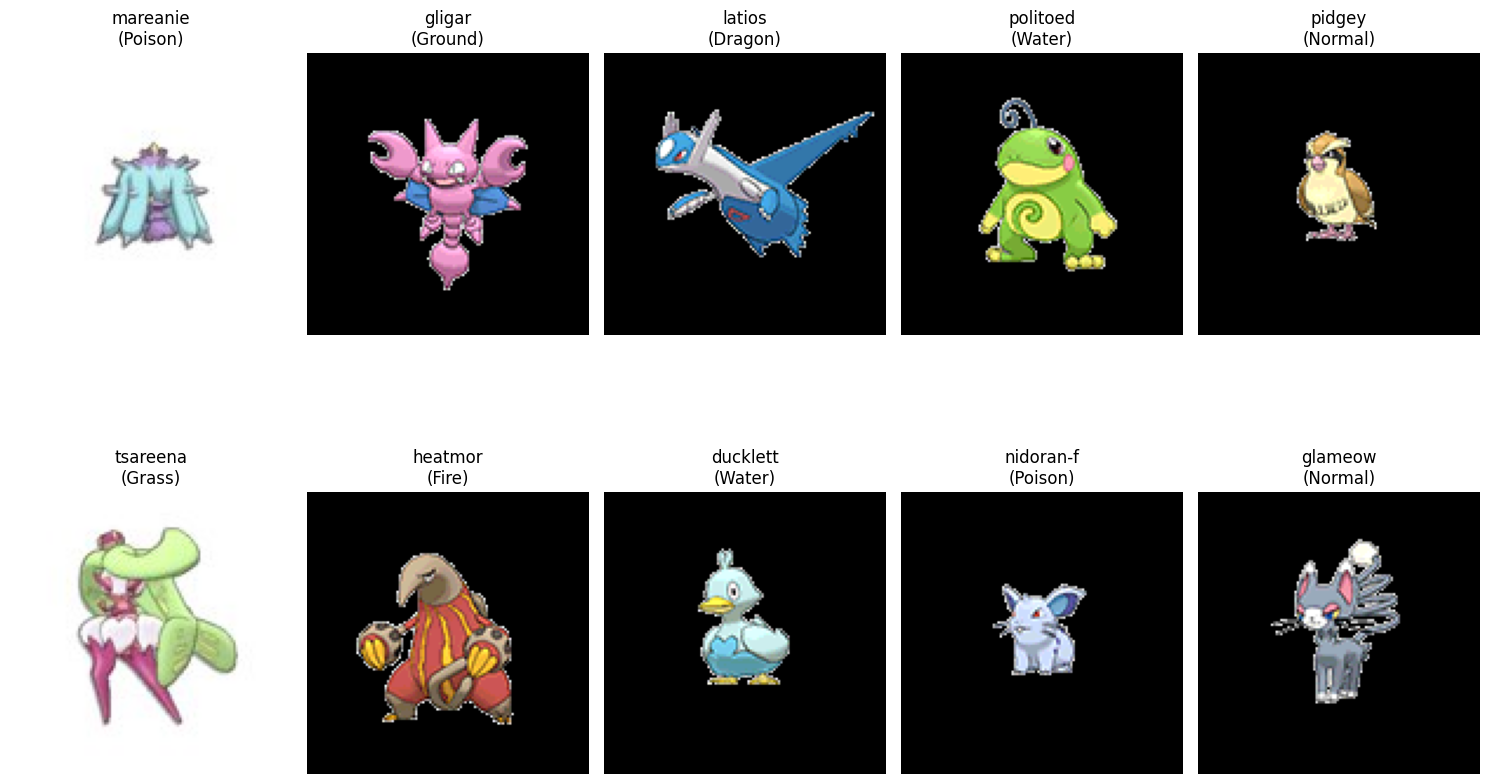

In [18]:
# Mostrar imágenes en un grid
plt.figure(figsize=(15, 10))

for i, row in enumerate(sample.itertuples(), 1):
    nombre = row.Name.strip()
    tipo = row.Type1

    # Buscar archivo con extensión válida
    for ext in [".png", ".jpg"]:
        filename = f"{nombre}{ext}"
        ruta = os.path.join(images_path, filename)
        if os.path.exists(ruta):
            img = Image.open(ruta).convert("RGB")
            break
    else:
        img = None

    # Mostrar imagen si existe
    plt.subplot(2, 5, i)
    if img:
        plt.imshow(img)
    plt.axis("off")
    plt.title(f"{nombre}\n({tipo})")

plt.tight_layout()
plt.show()

**Distribución de clases**

In [19]:
conteo = df_tipo1['Type1'].value_counts()

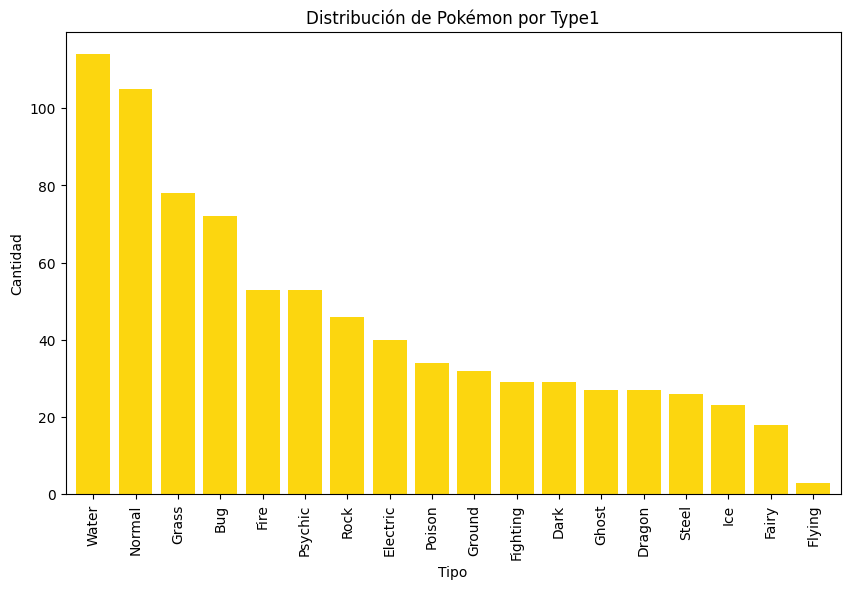

In [20]:
plt.figure(figsize=(10,6))
conteo.plot(kind='bar', color='#FCD60F', width=0.8)
plt.title("Distribución de Pokémon por Type1")
plt.xlabel("Tipo")
plt.ylabel("Cantidad")
plt.show()

<h2 style="color:#F54927; font-size: 1.2em; font-weight: bold;"> Normalización </h2>

Escalado de imágenes a [0, 1]

In [21]:
datagen = ImageDataGenerator(rescale=1./255)  # normalización

<h2 style="color:#F54927; font-size: 1.2em; font-weight: bold;"> Codificación </h2>

In [22]:
train_generator = datagen.flow_from_directory(
    os.path.join(output_path, "train"),
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical"
)

Found 972 images belonging to 18 classes.


In [23]:
val_generator = datagen.flow_from_directory(
    os.path.join(output_path, "val"),
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical"
)

Found 122 images belonging to 18 classes.


In [24]:
test_generator = datagen.flow_from_directory(
    os.path.join(output_path, "test"),
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical"
)

Found 120 images belonging to 18 classes.


<h2 style="background-color:#FAA493; color:#595959;">Paso 2: Modelado CNN - SingleLabel </h2> 

<h2 style="color:#F54927; font-size: 1.2em; font-weight: bold;"> Arquitectura CNN </h2>

In [25]:
num_classes = len(train_generator.class_indices)  # número de tipos de Pokémon

In [42]:
model = Sequential([
    # Bloque 1
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Bloque 2
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Bloque 3
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Bloque 4 (nuevo)
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

<h2 style="color:#F54927; font-size: 1.2em; font-weight: bold;"> Optimización </h2>

In [45]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [46]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 18)             │         9,234 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,118,674 (19.53 MB)

 Trainable params: 5,117,714 (19.52 MB)

 Non-trainable params: 960 (3.75 KB)

<h2 style="color:#F54927; font-size: 1.2em; font-weight: bold;"> Entrenamiento </h2>

In [47]:
## Evitar overffiting - EarlyStopping 
early_stop = EarlyStopping(
    monitor="val_loss", # métrica a monitorear ('val_accuracy' o 'val_loss')
    patience=5, # número de épocas sin mejora antes de detener
    restore_best_weights=True # restaura los pesos de la mejor época
)

In [48]:
%%time
history = model.fit(
    train_generator,
    epochs=100,
    batch_size=64,
    validation_data=val_generator,
    callbacks=[early_stop]
)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 387ms/step - accuracy: 0.0566 - loss: 6.8302 - val_accuracy: 0.0246 - val_loss: 3.1857
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 367ms/step - accuracy: 0.0988 - loss: 3.1533 - val_accuracy: 0.0574 - val_loss: 7.5900
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 351ms/step - accuracy: 0.1183 - loss: 2.9453 - val_accuracy: 0.0820 - val_loss: 8.2631
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 351ms/step - accuracy: 0.1132 - loss: 2.8828 - val_accuracy: 0.0820 - val_loss: 9.1224
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 353ms/step - accuracy: 0.1235 - loss: 2.8649 - val_accuracy: 0.0656 - val_loss: 7.6068
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 351ms/step - accuracy: 0.1101 - loss: 2.8611 - val_accuracy: 0.0574 - val_loss: 9.0576
CPU times: total: 5min 35s
Wall time: 1min 9s


<h2 style="color:#F54927; font-size: 1.2em; font-weight: bold;"> Evaluación </h2>

In [49]:
test_loss, test_acc = model.evaluate(test_generator)

print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.0500 - loss: 3.1729
Test accuracy: 0.05000000074505806
Test loss: 3.1729416847229004


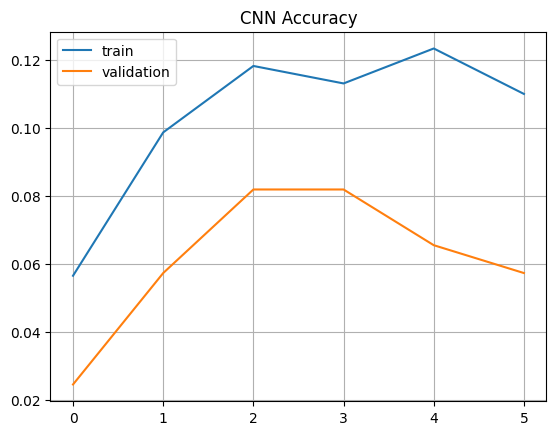

In [50]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")

plt.title("CNN Accuracy")
plt.legend()
plt.grid(True)
plt.show()

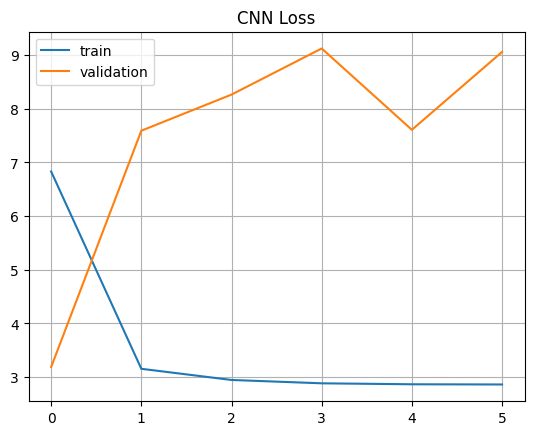

In [51]:
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")

plt.title("CNN Loss")
plt.legend()
plt.grid(True)
plt.show()